# Import Packages (Enhanced model)

In [1]:
import sys
print(sys.executable)

c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Scripts\python.exe


In [12]:
# univariate multi-step lstm for the power usage dataset

import time

# Start counting notebook running time
time_start = time.time()

import numpy as np
import tensorflow as tf
# Set all random seeds for the program (Python, NumPy, and TensorFlow)
tf.keras.utils.set_random_seed(1)

import pandas as pd
from  IPython.display import display, Image
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import Dense, Flatten, LSTM, RepeatVector, TimeDistributed, Dropout
from keras.layers import Conv1D, MaxPooling1D
from keras.utils import plot_model
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
import sklearn
import keras
import pandas as pd
from sklearn.preprocessing import StandardScaler
from time import strftime
current_time = strftime("%Y-%m-%d-%H-%M-%S")
print('current time: ', current_time)
print('numpy version: ', np.__version__)
print('tensorflow version: ', tf.__version__)
print('pandas version: ', pd.__version__)
print('scikit-learn version: ', sklearn.__version__)
print('keras version: ', keras.__version__)

current time:  2026-04-13-19-36-17
numpy version:  2.4.4
tensorflow version:  2.21.0
pandas version:  3.0.2
scikit-learn version:  1.8.0
keras version:  3.14.0


# Import Data¶
## Daily power data of all campus buildings of IIT Delhi

In [14]:
%%time
path ='C:\\Users\\xin37\\github\\CNN-LSTM-model-for-energy-usage-forecasting-1\\data\\cold_source_control_dataset.csv'
data = pd.read_csv(
    path,
    header=0, 
    parse_dates=['Timestamp'], 
    index_col=['Timestamp']
)
print(data.shape)
display(data.head())

(3498, 11)


,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output
Timestamp,,,,,,,,,,,
2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1
2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4
2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4
2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3
2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4


CPU times: total: 15.6 ms
Wall time: 31.3 ms


# Visualize sample data

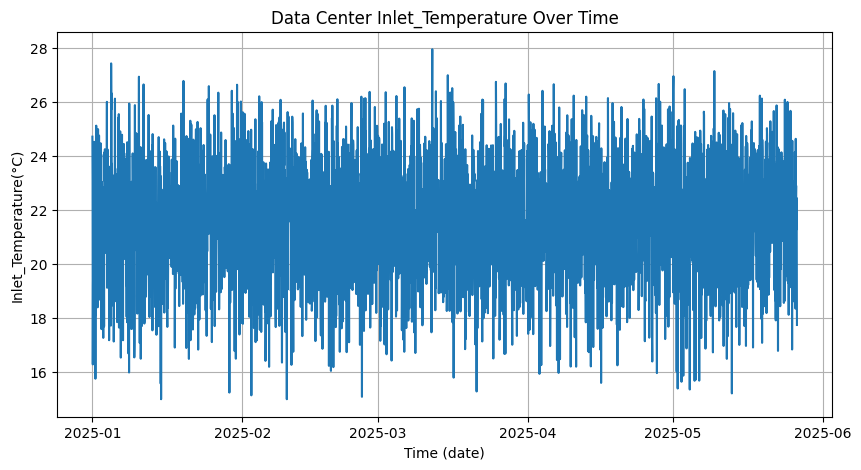

CPU times: total: 125 ms
Wall time: 128 ms


In [15]:
%%time
fig = plt.figure(figsize=(10, 5));
plt.plot(data.index, data['Inlet_Temperature(°C)']) 

plt.xlabel('Time (date)')
plt.ylabel('Inlet_Temperature(°C)')
plt.title('Data Center Inlet_Temperature Over Time')
plt.grid(True) # Added for better readability
plt.show()

# Split a dataset into train/test sets

In [43]:
n_input  = 24   # past 24 hours
n_output = 1    # predict next 1 hour
test_size = 24 * 7  # last 1 week for testing

FEATURE_COLS = [
    'Server_Workload(%)',
    'Ambient_Temperature(°C)',
    'Cooling_Unit_Power_Consumption(kW)',
    'Chiller_Usage(%)',
    'AHU_Usage(%)',
]
TARGET_COL = 'Inlet_Temperature(°C)'

def split_dataset(data, test_size_hours):
    split = len(data) - test_size_hours
    X = data[FEATURE_COLS].values
    y = data[TARGET_COL].values
    return X[:split], y[:split], X[split:], y[split:]

#  Format the data in the overlapping moving window format¶
We need to restrucutre the time-series data in order for training and making predictions like a supervised machine learning model. For every n_input sequence of data, the n_ouput sequence will be target values. We will also increment the sequences by 1 each time to utilise the so called overlapping window format.

In [46]:
def make_windows(X, y, n_input):
    """Slide a window over X/y to produce (samples, n_input, n_features) tensors."""
    Xs, ys = [], []
    for i in range(len(X) - n_input):
        Xs.append(X[i : i + n_input, :])
        ys.append(y[i + n_input])           # single next-step target
    return np.array(Xs), np.array(ys).reshape(-1, 1)

# Define function for building model
In this model architecture, a one-dimensional convolutional neural network (1D CNN) is used to read and encode the input sequence. An LSTM network is then used as a decoder to make ode-step prediction for each value in the output sequence.

In [68]:
# Global variable to store history
training_history = None

# build and train the model
def build_model(X_train, y_train, X_val, y_val, n_input):
    global training_history
    # specify model parameters
    X_seq_tr, y_seq_tr   = make_windows(X_train, y_train, n_input)
    X_seq_val, y_seq_val = make_windows(X_val, y_val, n_input)

    n_features = X_seq_tr.shape[2]

    # define model
    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=(n_input, n_features)),
        Conv1D(32, 3, activation='relu'),
        MaxPooling1D(),
        Dropout(0.3),
        Flatten(),
        #-------CNN-------
        #-------LSTM-------
        RepeatVector(1),
        LSTM(64, activation='relu', return_sequences=False),
        Dropout(0.3),
        #-------LSTM-------
        Dense(1),
    ])

    model.compile(loss='mse', optimizer='adam')
    model.summary()

    # fit network and save the history
    training_history = model.fit(X_seq_tr, y_seq_tr, epochs=100, batch_size= 16, verbose= 1, validation_data=(X_seq_val, y_seq_val))

    return model, training_history

# Define function for evaluating model

In [69]:
def evaluate_model(X_train, X_test, n_input, model):
    buffer = X_train[-n_input:].copy()
    predictions = []

    for i in range(len(X_test)):
        x_in = buffer.reshape(1, n_input, buffer.shape[1])
        yhat = model.predict(x_in, verbose=0)
        predictions.append(float(yhat[0, 0]))

        buffer = np.vstack([buffer[1:], X_test[i:i+1, :]])

    return np.array(predictions)

# Train model and make predictions

In [70]:
%%time
import tensorflow as tf

# clear old model from memory
tf.keras.backend.clear_session()

n_input = 24  # past 24 hours
n_output = 1  # single step prediction

# split into train and test
X_train, y_train, X_test, y_test = split_dataset(data, test_size)

# 2. split train into train + val BEFORE scaling
val_size = int(len(X_train) * 0.2)
X_tr,  X_val  = X_train[:-val_size], X_train[-val_size:]
y_tr,  y_val  = y_train[:-val_size], y_train[-val_size:]

# scale the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_tr_scaled   = scaler_X.fit_transform(X_tr)
X_val_scaled  = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_tr_scaled  = scaler_y.fit_transform(y_tr.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()

# build model
model, history = build_model(X_tr_scaled, y_tr_scaled, X_val_scaled, y_val_scaled, n_input)

# evaluate
predictions_scaled = evaluate_model(X_tr_scaled, X_test_scaled, n_input, model)

# inverse transform predictions back to original scale
predictions = scaler_y.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

print('predicted temperatures: ', len(predictions))

c:\Users\xin37\github\CNN-LSTM-model-for-energy-usage-forecasting-1\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 22, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 320)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,241 (399.38 KB)

 Trainable params: 102,241 (399.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.0072 - val_loss: 1.0464
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9922 - val_loss: 1.0475
Epoch 3/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9851 - val_loss: 1.0528
Epoch 4/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9706 - val_loss: 1.0498
Epoch 5/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9676 - val_loss: 1.0601
Epoch 6/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9524 - val_loss: 1.0599
Epoch 7/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9313 - val_loss: 1.0597
Epoch 8/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9013 - val_loss: 1.0719
Epoch 9/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8822 - val_loss: 1.0756
Epoch 10/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8224 - val_loss: 1.0822
Epoch 11/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8070 - val_loss: 1.0808
Epoch 12/100
165/165 ━━━━━━━━━━━━━━━━━━━━

# Visualize model architecture

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


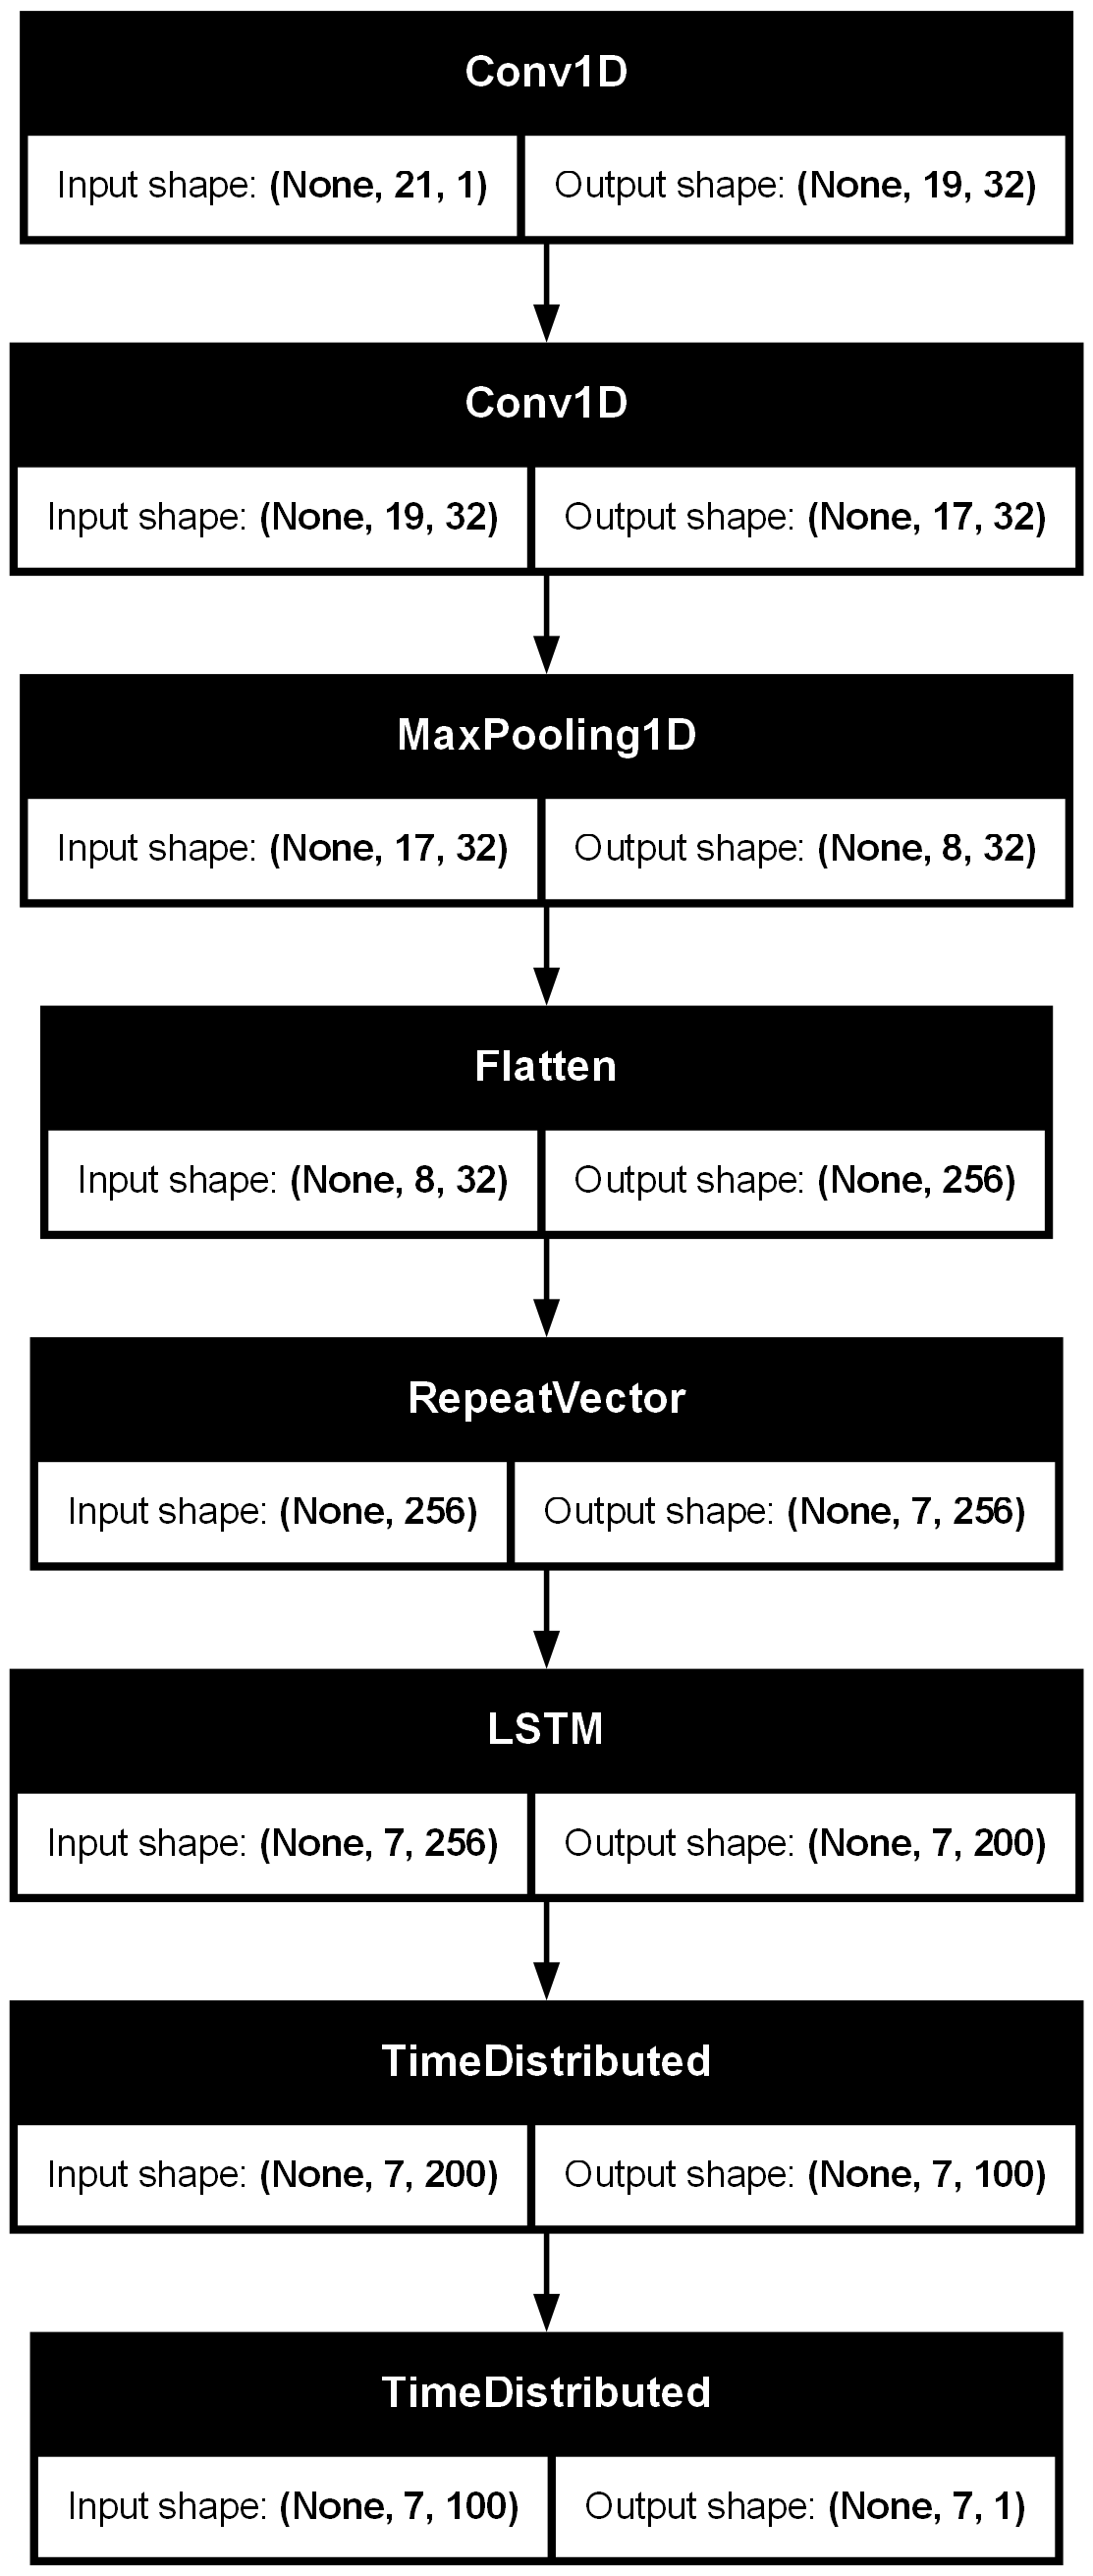

In [63]:
from IPython.display import Image, display
from tensorflow.keras.utils import plot_model

# model is already built, no need to call build_model again
# just plot and display directly

plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
display(Image(filename='model_architecture.png'))

# Compare actual and predicted values

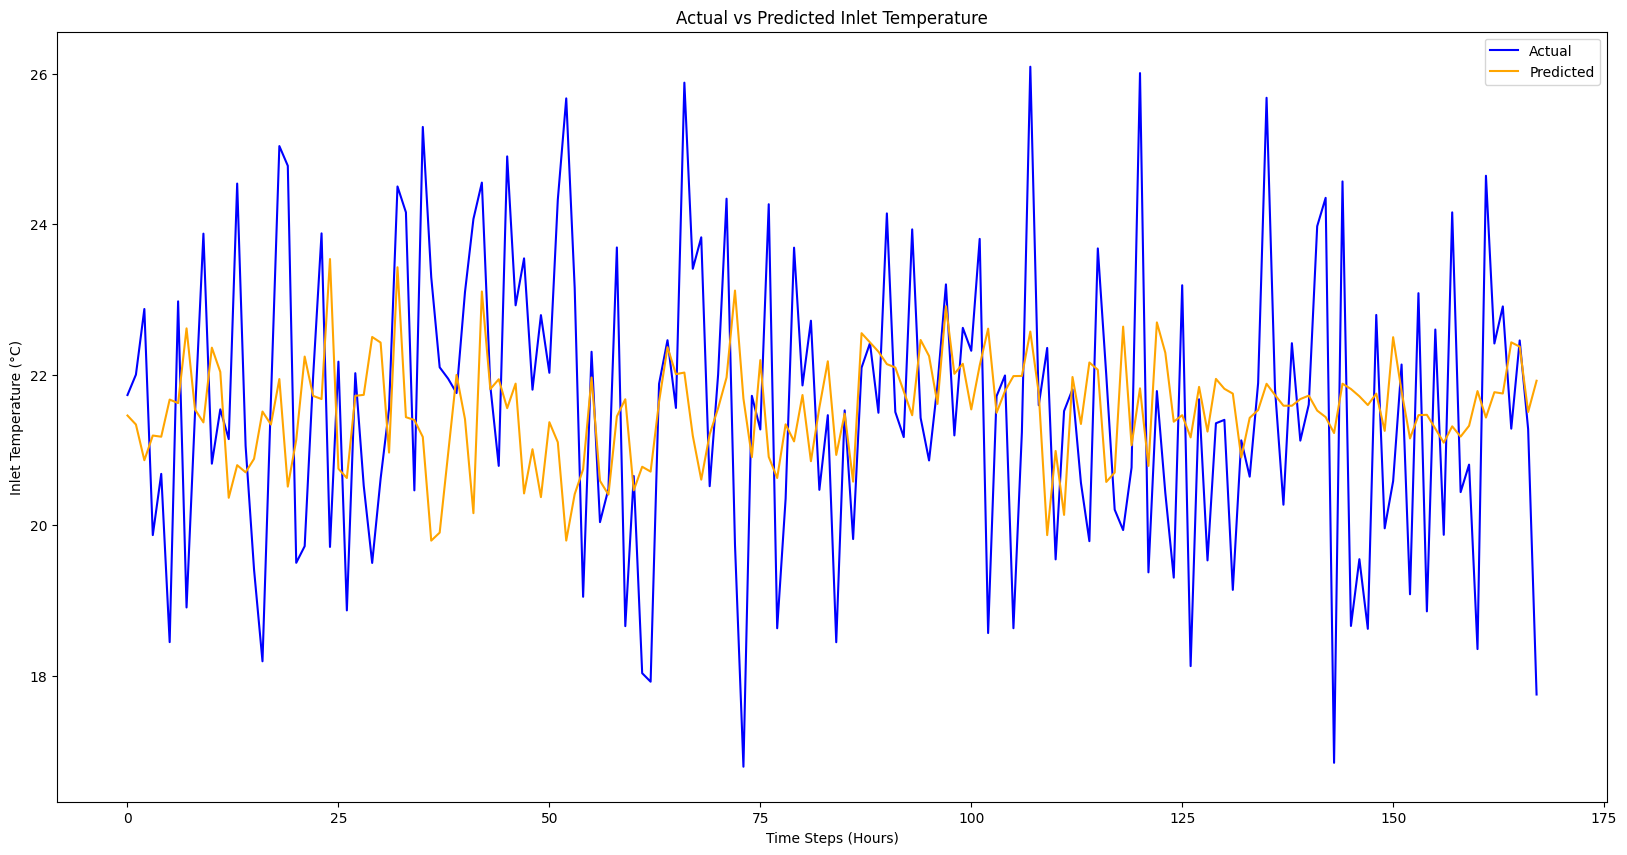

In [71]:
def plot_predictions(actual, predicted, n_output):
    fig = plt.figure(figsize=(20, 10))
    plt.plot(actual, label='Actual', color='blue')
    plt.plot(predicted, label='Predicted', color='orange')
    plt.xlabel('Time Steps (Hours)')
    plt.ylabel('Inlet Temperature (°C)')
    plt.title('Actual vs Predicted Inlet Temperature')
    plt.legend()
    plt.show()

# actual values from test set
actual = y_test  # already a 1D numpy array

# predictions is already 1D, no reshape needed
predictions_flat = predictions  

# plot
plot_predictions(actual, predictions_flat, n_output)

# RMSE for all sequences

In [72]:
def return_rmse(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))

return_rmse(actual, predictions_flat)

The root mean squared error is 2.09.


In [73]:
time_end = time.time()
print("Notebook run time: {:.0f} seconds".format(time_end - time_start))

Notebook run time: 7234 seconds


## Performance metric for the baseline model (CNN-LSTM) and Models training loss and validation loss

Root Mean Squared Error (RMSE): 2.09
Mean Absolute Error (MAE): 1.66
R-squared Score (R2): -0.12


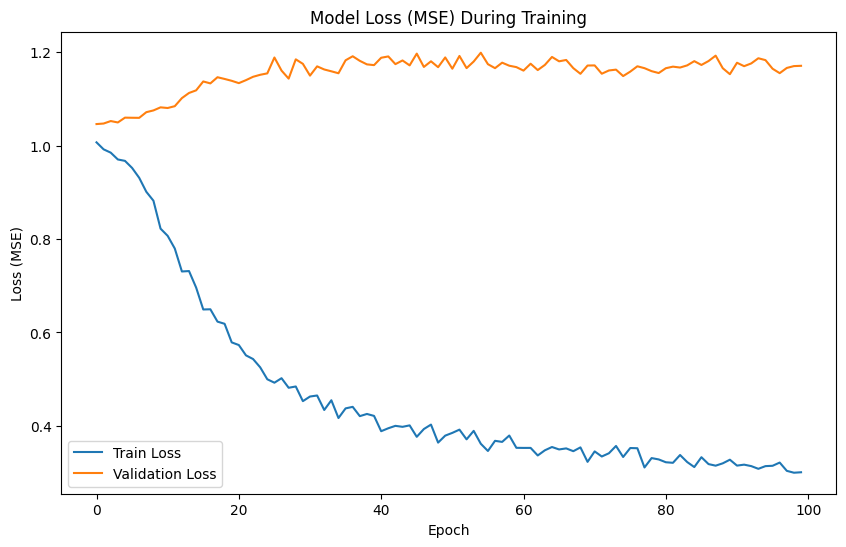

In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def return_performance_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared Score (R2): {r2:.2f}")
    
    return rmse, mae, r2
metrics = return_performance_metrics(actual, predictions_flat)

plt.figure(figsize=(10, 6))
plt.plot(training_history.history['loss'], label='Train Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE) During Training')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()
